In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("tech_layoffs_2026_tracker.csv")

In [12]:
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [13]:
print(df.shape)

(28, 26)


In [14]:
print(df.columns)

Index(['company', 'layoff_date', 'jobs_cut', 'pct_workforce_cut', 'sector',
       'country', 'hq_city', 'ai_cited', 'reason_stated',
       'company_revenue_2025_bn', 'pre_layoff_headcount',
       'stock_change_day_pct', 'simultaneous_ai_investment_bn',
       'roles_most_affected', 'replacement_roles', 'ceo_quote', 'layoffs_2024',
       'layoffs_2025', 'verified_source', 'month', 'quarter', 'region',
       'layoff_size_category', 'stock_reaction', 'laid_off_vs_headcount_pct',
       'data_as_of'],
      dtype='object')


In [15]:
df.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [18]:
df["roles_clean"]=df["roles_most_affected"].astype(str).str.lower()

In [20]:
total_layoffs=df["jobs_cut"].sum()
avg_layoffs=df["jobs_cut"].mean()

In [21]:
print("Total Layoffs:",total_layoffs)

Total Layoffs: 101146


In [22]:
print("Average Layoffs:",avg_layoffs)

Average Layoffs: 3612.3571428571427


In [23]:
top_roles=df["roles_clean"].value_counts().head(10)

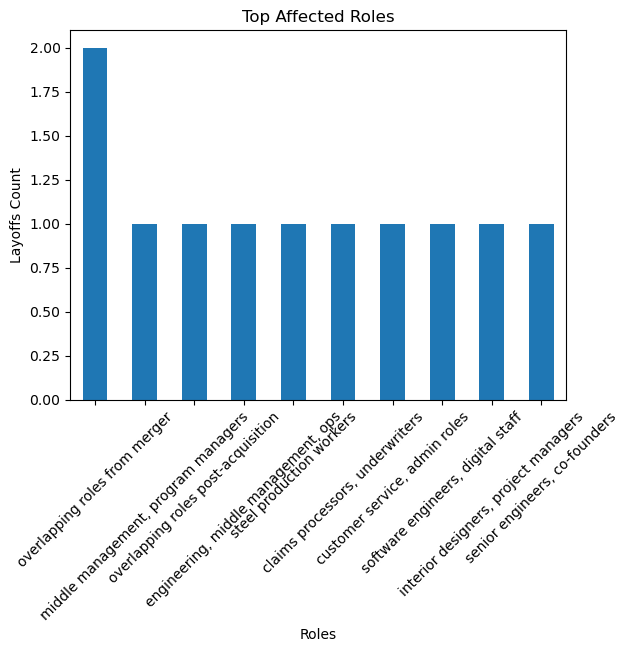

In [24]:
top_roles.plot(kind="bar")
plt.title("Top Affected Roles")
plt.xlabel("Roles")
plt.ylabel("Layoffs Count")
plt.xticks(rotation=45)
plt.show()

In [25]:
company_layoffs=df.groupby("company")["jobs_cut"].sum().sort_values(ascending=False).head(10)

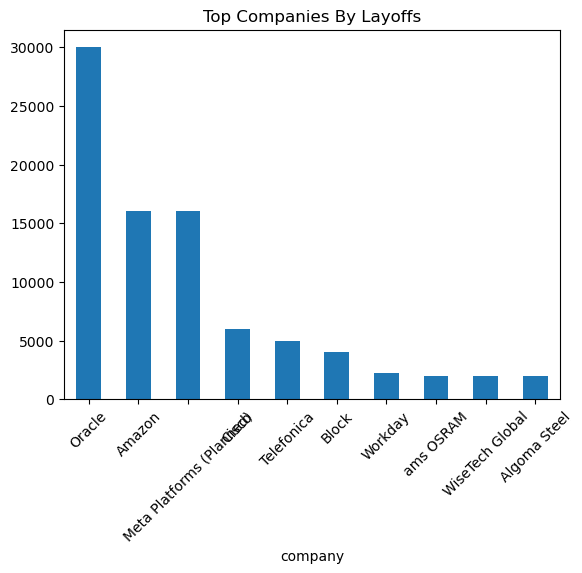

In [28]:
company_layoffs.plot(kind="bar")
plt.title("Top Companies By Layoffs")
plt.xticks(rotation=45)
plt.show()

In [29]:
country_layoffs=df.groupby("country")["jobs_cut"].sum().sort_values(ascending=False).head(10)

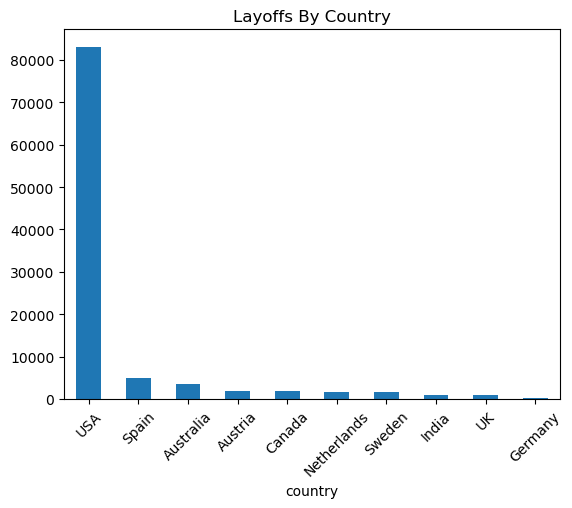

In [30]:
country_layoffs.plot(kind="bar")
plt.title("Layoffs By Country")
plt.xticks(rotation=45)
plt.show()

In [31]:
sector_layoffs=df.groupby("sector")["jobs_cut"].sum().sort_values(ascending=False).head(10)

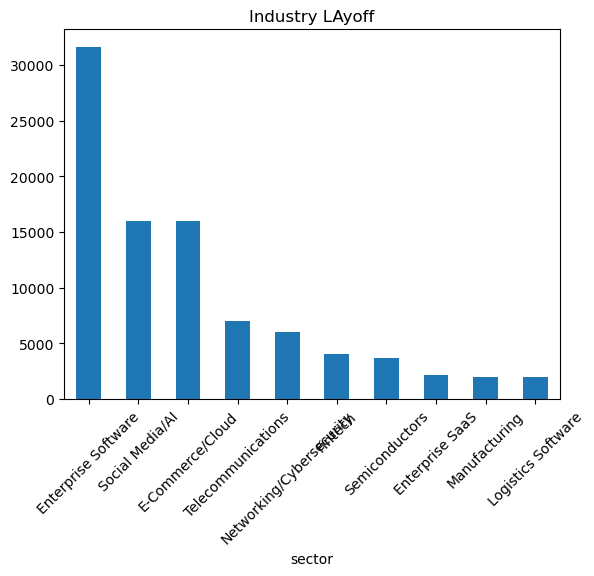

In [32]:
sector_layoffs.plot(kind="bar")
plt.title("Industry LAyoff")
plt.xticks(rotation=45)
plt.show()

In [34]:
df["layoff_date"]=pd.to_datetime(df["layoff_date"])

In [36]:
monthly=df.groupby(df["layoff_date"].dt.to_period("M"))["jobs_cut"].sum()

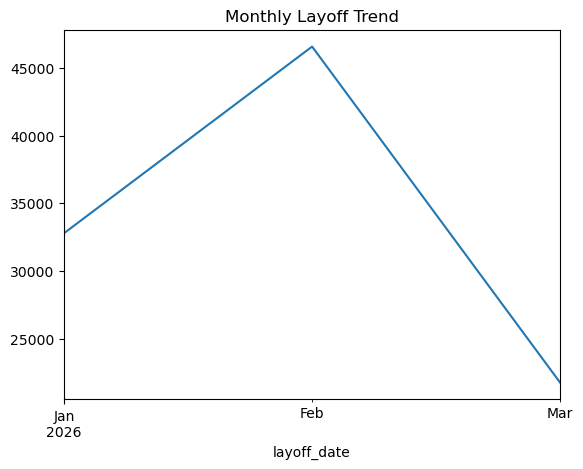

In [37]:
monthly.plot()
plt.title("Monthly Layoff Trend")
plt.show()

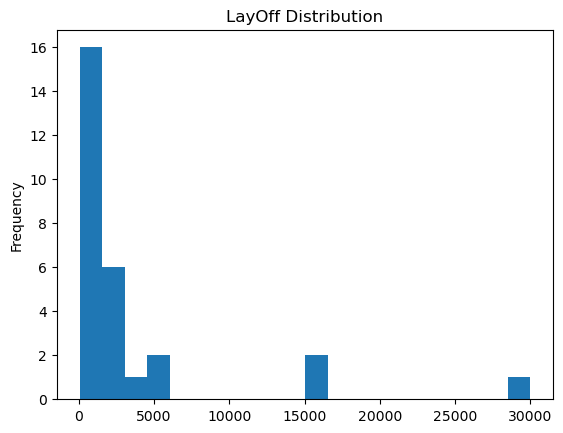

In [38]:
df["jobs_cut"].plot(kind="hist",bins=20)
plt.title("LayOff Distribution")
plt.show()

In [39]:
role_layoffs=df.groupby("roles_clean")["jobs_cut"].sum().sort_values(ascending=False).head(10)

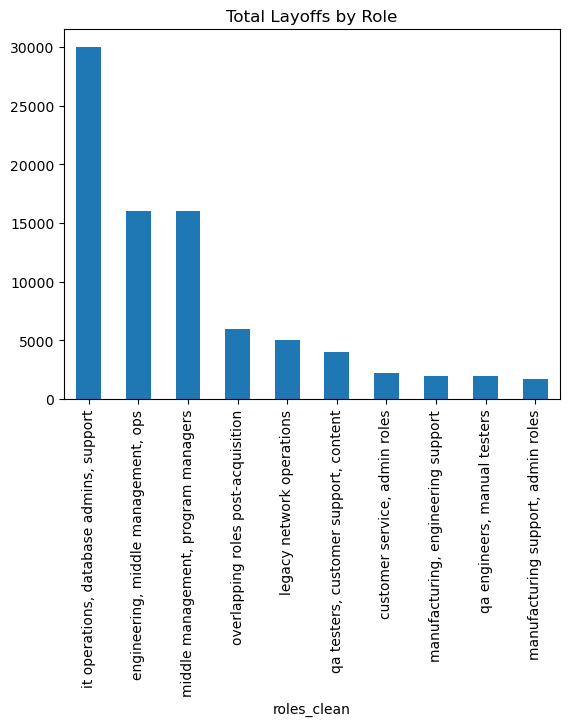

In [40]:
role_layoffs.plot(kind="bar")
plt.title("Total Layoffs by Role")
plt.show()

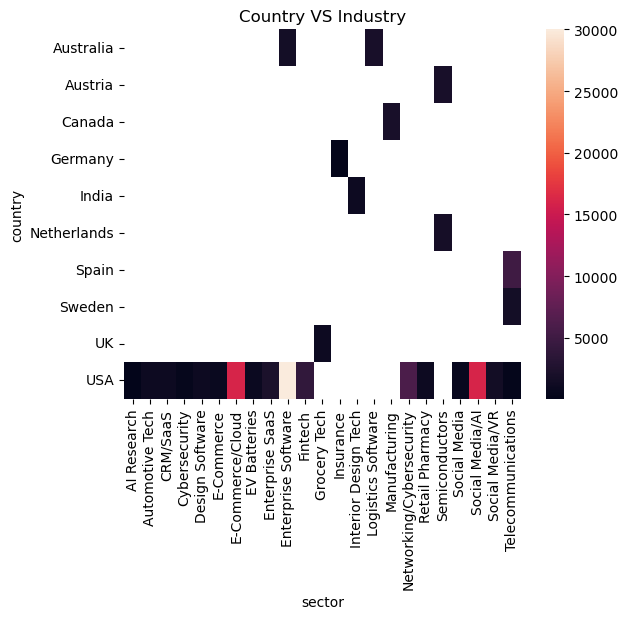

In [42]:
pivot=pd.pivot_table(df,values="jobs_cut",index="country",columns="sector",aggfunc="sum")
sns.heatmap(pivot)
plt.title("Country VS Industry")
plt.show()

In [43]:
df=df.sort_values("layoff_date")
df["cumulative"]=df["jobs_cut"].cumsum()

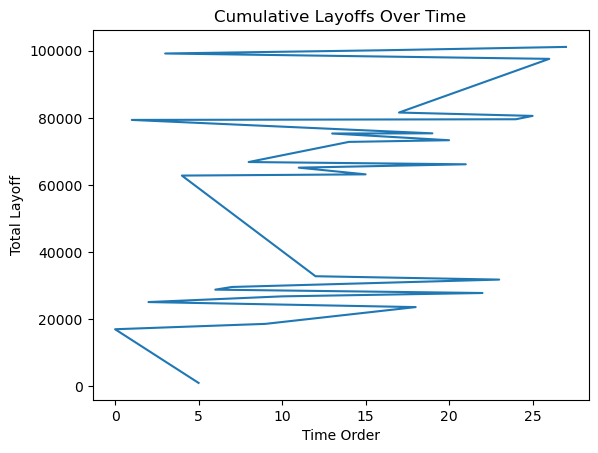

In [44]:
df["cumulative"].plot()
plt.title("Cumulative Layoffs Over Time")
plt.xlabel("Time Order")
plt.ylabel("Total Layoff")
plt.show()

In [ ]:
# 100
# 200
# 300

# 100
# 300(100+200)
# 600(300+300)

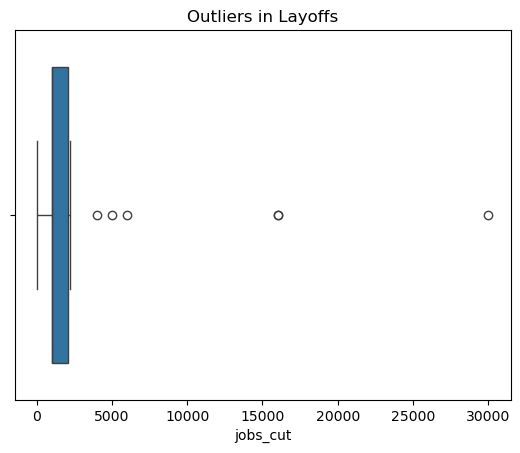

In [45]:
sns.boxplot(x=df["jobs_cut"])
plt.title("Outliers in Layoffs")
plt.show()

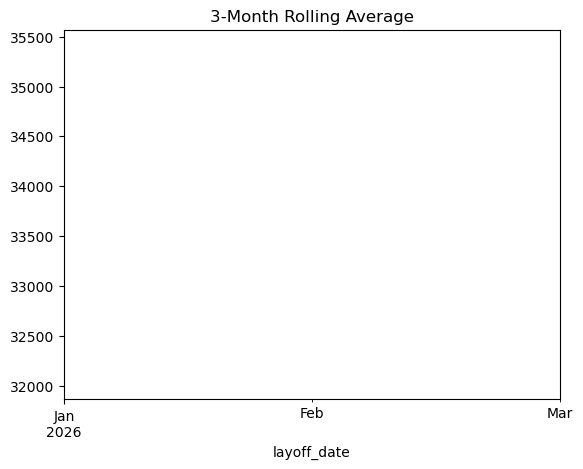

In [47]:
rolling_avg=monthly.rolling(3).mean()
rolling_avg.plot()
plt.title("3-Month Rolling Average")
plt.show()

In [48]:
company_total=df.groupby("company")["jobs_cut"].sum()
company_percent=(company_total/company_total.sum())*100

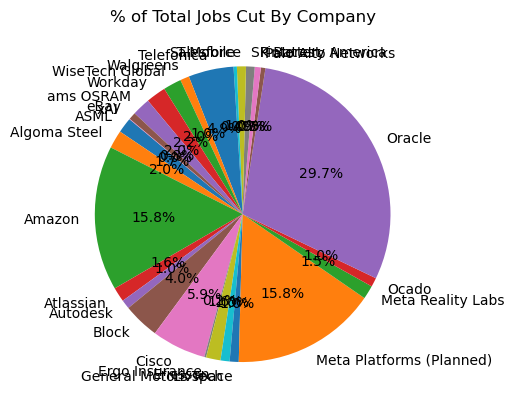

In [54]:
company_total.plot(kind="pie",
                  autopct="%1.1f%%",
                  startangle=140)
plt.title("% of Total Jobs Cut By Company")
plt.ylabel("")
plt.show()

In [55]:
yearly=df.groupby(df["layoff_date"].dt.year)["jobs_cut"].sum()
growth=yearly.pct_change()*100

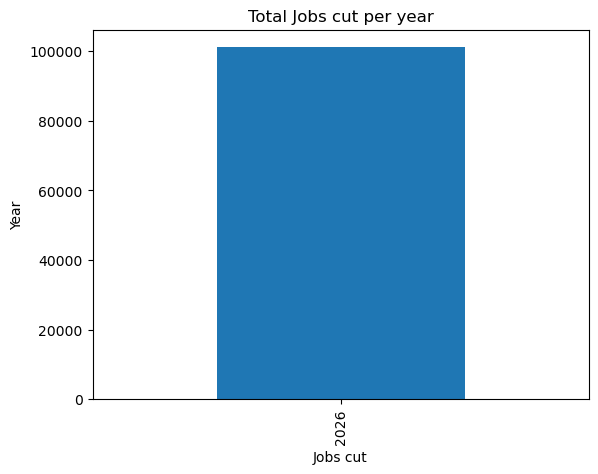

In [56]:
yearly.plot(kind="bar")
plt.title("Total Jobs cut per year")
plt.xlabel("Jobs cut")
plt.ylabel("Year")
plt.show()

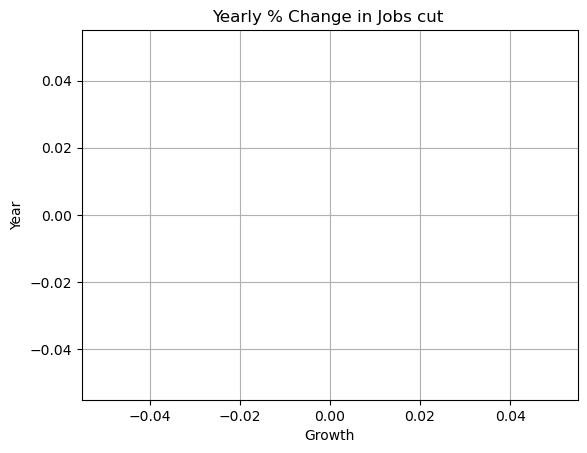

In [57]:
growth.plot(kind="line")
plt.title("Yearly % Change in Jobs cut ")
plt.xlabel("Growth")
plt.ylabel("Year")
plt.grid(True)
plt.show()